In [2]:
# Setup imports and paths
import os
import json
import math
from typing import List, Dict, Optional
import pandas as pd

# Workspace paths 
SADA_DIR = os.path.join(os.getcwd(), 'sada2022_data')
OUT_PATH = os.path.join(os.getcwd(), 'data', 'eou_dataset.jsonl')
SILENCE_THRESHOLD = 0.8  # seconds to consider a turn-end by silence

print('SADA_DIR =', SADA_DIR)
print('OUT_PATH =', OUT_PATH)


SADA_DIR = c:\Users\rkhm3\Desktop\EOU_Model\sada2022_data
OUT_PATH = c:\Users\rkhm3\Desktop\EOU_Model\data\eou_dataset.jsonl


# EOU dataset extraction and augmentation
This notebook creates a labelled dataset for End-Of-Utterance (EOU) detection from the SADA corpus.

It implements: extraction from SADA CSVs, rule-based EOU labeling (silence + punctuation), a probabilistic label heuristic, Saudi-focused augmentation, pause token insertion, oversampling, and export to JSONL.

In [3]:
# Helper functions: labeling and augmentation
TERMINAL_PUNCT = set(['.', '!', '؟', '?', '»'])


def is_terminal_punctuation(text: str) -> bool:
    if not isinstance(text, str) or not text:
        return False
    text = text.strip()
    return any(text.endswith(p) for p in TERMINAL_PUNCT)


def build_examples_from_dataframe(df: pd.DataFrame, split: str, silence_threshold: float = 0.8, prob_label: bool = False) -> List[Dict]:
    examples: List[Dict] = []

    expected_cols = {'FileName', 'SegmentStart', 'SegmentEnd', 'Speaker', 'GroundTruthText', 'ProcessedText', 'SpeakerDialect'}
    missing = expected_cols - set(df.columns)
    if missing:
        raise ValueError(f'Missing expected columns in dataframe: {missing}')

    for file_name, group in df.groupby('FileName'):
        group_sorted = group.sort_values(by='SegmentStart')
        rows = group_sorted.to_dict(orient='records')

        for idx, row in enumerate(rows):
            start_time = float(row.get('SegmentStart', 0.0))
            end_time = float(row.get('SegmentEnd', 0.0))
            speaker_id = row.get('Speaker')
            raw_text = row.get('GroundTruthText') if row.get('GroundTruthText') is not None else ''
            text = row.get('ProcessedText') if row.get('ProcessedText') is not None else raw_text
            dialect = row.get('SpeakerDialect') if row.get('SpeakerDialect') is not None else 'Unknown'

            if idx < len(rows) - 1:
                next_row = rows[idx + 1]
                next_start = float(next_row.get('SegmentStart', 0.0))
                silence_after_seconds = max(0.0, next_start - end_time)
                next_speaker = next_row.get('Speaker')
            else:
                silence_after_seconds = float('nan')
                next_speaker = None

            ended_by_silence = False
            if not math.isnan(silence_after_seconds) and silence_after_seconds > silence_threshold:
                ended_by_silence = True

            ended_by_punct_and_turn = False
            if next_speaker is not None and next_speaker != speaker_id and is_terminal_punctuation(raw_text):
                ended_by_punct_and_turn = True

            label = 1 if (ended_by_silence or ended_by_punct_and_turn) else 0

            prob = None
            if prob_label:
                if ended_by_silence:
                    prob = min(0.99, 0.7 + (silence_after_seconds - silence_threshold) / max(1.0, silence_after_seconds))
                elif ended_by_punct_and_turn:
                    prob = 0.8
                else:
                    if math.isnan(silence_after_seconds):
                        prob = 0.4
                    else:
                        prob = max(0.01, 0.4 - (silence_threshold - silence_after_seconds) / max(1.0, silence_threshold))

            example = {
                'text': text,
                'raw_text': raw_text,
                'label': int(label),
                'prob_label': float(prob) if prob is not None else None,
                'start_time': float(start_time),
                'end_time': float(end_time),
                'speaker_id': speaker_id,
                'dialect': dialect,
                'silence_after_seconds': None if math.isnan(silence_after_seconds) else float(silence_after_seconds),
                'file_name': file_name,
                'split': split,
            }

            examples.append(example)

    return examples


In [5]:
# Augmentation and helpers for pause tokens
import pandas as pd

def simple_saudi_augment(example: Dict) -> Dict:
    """Conservative rule-based Saudi-style augmentation.

    Handles non-string inputs safely by coercing to empty string when necessary.
    """
    replacements = {
        'كيف': 'شلون',
        'أين': 'وين',
        'لا': 'لاا',
        'نعم': 'ايه',
        'ما': 'مو',
        'أنت': 'إنتا',
        'ايش': 'ويش',
        'ليش': 'لاش',
        'نحن': 'حنا',
        'هل': 'ها',
        'لم': 'ما',
        'لن': 'ما راح',
    }

    # Safely obtain text (prefer processed text, then raw text). Guard against NaN/float.
    text_val = example.get('text') if example.get('text') is not None else example.get('raw_text')
    if isinstance(text_val, float) and math.isnan(text_val):
        text_val = ''
    if text_val is None:
        text_val = ''
    # ensure a string
    text = str(text_val)

    augmented = text
    for src, tgt in replacements.items():
        augmented = augmented.replace(src, tgt)

    # Insert a small filler to simulate hesitations, only when there's content
    if len(augmented.strip()) > 0 and len(augmented.split()) > 1:
        augmented = augmented + ' اممم'

    new_example = dict(example)
    new_example['text'] = augmented
    new_example['augment_type'] = 'saudi_rule'
    return new_example


def add_pause_tokens(example: Dict, threshold_for_pause_token: float = 0.5) -> Dict:
    new_example = dict(example)
    silence = example.get('silence_after_seconds')
    # If text missing, fallback to raw_text or empty string
    base_text = new_example.get('text') if new_example.get('text') is not None else new_example.get('raw_text')
    if isinstance(base_text, float) and math.isnan(base_text):
        base_text = ''
    if base_text is None:
        base_text = ''
    # ensure string for string ops
    base_text = str(base_text)

    if silence is None:
        new_example['text_with_pause'] = base_text
    else:
        token = f'[PAUSE_{silence:.2f}]' if silence >= threshold_for_pause_token else ''
        if token:
            new_example['text_with_pause'] = base_text.strip() + ' ' + token
        else:
            new_example['text_with_pause'] = base_text
    return new_example


In [6]:
# Process SADA splits and write output
os.makedirs(os.path.dirname(OUT_PATH), exist_ok=True)
splits = [('train.csv','train'), ('valid.csv','validation'), ('test.csv','test')]
all_examples = []
for fname, split in splits:
    path = os.path.join(SADA_DIR, fname)
    if not os.path.exists(path):
        print(f'Warning: {path} not found, skipping')
        continue
    try:
        usecols = ['FileName','SegmentStart','SegmentEnd','Speaker','GroundTruthText','ProcessedText','SpeakerDialect']
        df = pd.read_csv(path, usecols=usecols, dtype={'FileName':str,'Speaker':str,'SpeakerDialect':str}, low_memory=False)
    except Exception as e:
        print('Error reading', path, e)
        continue
    examples = build_examples_from_dataframe(df, split, silence_threshold=SILENCE_THRESHOLD, prob_label=True)
    all_examples.extend(examples)

print('Base examples:', len(all_examples))

# Apply Saudi augmentation conservatively and add pause text variants
augmented = []
for ex in all_examples:
    dialect = (ex.get('dialect') or '').lower()
    if 'naj' in dialect or 'khal' in dialect or 'hij' in dialect:
        augmented.append(simple_saudi_augment(ex))

final_examples = []
for ex in all_examples:
    final_examples.append(add_pause_tokens(ex))
final_examples.extend(augmented)

# Basic balancing: oversample non-EOU if dataset is imbalanced (factor=1 means no oversampling)
oversample_factor = 1.0
if oversample_factor > 1.0:
    non_eou = [e for e in final_examples if e.get('label') == 0]
    for _ in range(int(oversample_factor)-1):
        final_examples.extend([dict(e) for e in non_eou])

print('Final examples:', len(final_examples))

# write JSONL
with open(OUT_PATH, 'w', encoding='utf8') as fh:
    for ex in final_examples:
        fh.write(json.dumps(ex, ensure_ascii=False) + '\n')

print('Wrote dataset to', OUT_PATH)


Base examples: 253166
Final examples: 414267
Wrote dataset to c:\Users\rkhm3\Desktop\EOU_Model\data\eou_dataset.jsonl


In [7]:
# Spot check few examples for manual review
def spot_check(path: str, n: int = 10):
    samples = []
    if not os.path.exists(path):
        print('No dataset found at', path)
        return samples
    with open(path, 'r', encoding='utf8') as fh:
        for i, line in enumerate(fh):
            if i >= n:
                break
            samples.append(json.loads(line))
    return samples

samples = spot_check(OUT_PATH, n=12)
for s in samples:
    print('---')
    print('text:', s.get('text'))
    print('text_with_pause:', s.get('text_with_pause'))
    print('label:', s.get('label'), 'prob_label:', s.get('prob_label'))
    print('silence_after_seconds:', s.get('silence_after_seconds'))


---
text: ووضح كلامك يا مغيث
text_with_pause: ووضح كلامك يا مغيث [PAUSE_0.86]
label: 1 prob_label: 0.7599999999999851
silence_after_seconds: 0.8599999999999852
---
text: ترى راسي ما عاد يتحمل الغازك
text_with_pause: ترى راسي ما عاد يتحمل الغازك [PAUSE_0.71]
label: 1 prob_label: 0.8
silence_after_seconds: 0.7099999999999795
---
text: سلامة راسك يا ابو مسامح
text_with_pause: سلامة راسك يا ابو مسامح [PAUSE_1.38]
label: 1 prob_label: 0.99
silence_after_seconds: 1.3799999999999955
---
text: ما يصير يا ابو مسامح تخلي البنت في البيت دون امها
text_with_pause: ما يصير يا ابو مسامح تخلي البنت في البيت دون امها [PAUSE_5.09]
label: 1 prob_label: 0.99
silence_after_seconds: 5.089999999999975
---
text: ويش فيها لقعدت في البيت دون امها ما هو ده بيت ابوها هو بيت اجار
text_with_pause: ويش فيها لقعدت في البيت دون امها ما هو ده بيت ابوها هو بيت اجار [PAUSE_1.22]
label: 1 prob_label: 0.99
silence_after_seconds: 1.2200000000000273
---
text: الا بيت ابوها لكن لا تنسى انك حطمت حياتها
text_with_pause: الا بيت

**README / Notes**
- **Label rules**: label=1 when silence after segment > `SILENCE_THRESHOLD` OR when transcription ends with terminal punctuation and next speaker is different.
- **Probabilistic labels**: heuristic score captured in `prob_label` for calibration experiments.
- **Augmentation**: small rule-based Saudi paraphrases and filler insertion for realism.
- **Pause tokens**: `text_with_pause` contains inserted `[PAUSE_X]` tokens when silence >= 0.5s.
- **Output**: `data/eou_dataset.jsonl` with fields: `text`, `raw_text`, `label`, `prob_label`, `start_time`, `end_time`, `speaker_id`, `dialect`, `silence_after_seconds`, `file_name`, `split`.
- **Ethics**: SADA is CC BY-NC-SA 4.0; ensure any public release follows license and removes PII if necessary.


In [8]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import numpy as np

PATH = OUT_PATH  # eou_dataset.jsonl

print("Loading full dataset for EDA...")
examples = []
with open(PATH, 'r', encoding='utf-8') as f:
    for i, line in enumerate(f):
        if i % 100000 == 0:
            print(f"   ... {i:,} lines")
        line = line.strip()
        if not line:
            continue
        examples.append(json.loads(line))

df = pd.DataFrame(examples)
print(f"\nLOADED {len(df):,} examples\n")
print("="*70)


Loading full dataset for EDA...
   ... 0 lines
   ... 100,000 lines
   ... 200,000 lines
   ... 300,000 lines
   ... 400,000 lines

LOADED 414,267 examples



In [9]:

# 1. Basic info & missing values
print("1. Columns & missing counts")
print(df.count().sort_values())
print("\nMissing summary:")
print(df.isna().sum()[df.isna().sum() > 0])


1. Columns & missing counts
augment_type             161101
text_with_pause          253166
silence_after_seconds    407740
text                     414053
raw_text                 414266
label                    414267
prob_label               414267
start_time               414267
end_time                 414267
speaker_id               414267
dialect                  414267
file_name                414267
split                    414267
dtype: int64

Missing summary:
text                        214
raw_text                      1
silence_after_seconds      6527
text_with_pause          161101
augment_type             253166
dtype: int64


In [10]:

# 2. Label distribution
print("\n2. Label distribution")
print(df['label'].value_counts(normalize=True).mul(100).round(2).astype(str) + "%")
print(df['label'].value_counts())


2. Label distribution
label
1    75.16%
0    24.84%
Name: proportion, dtype: object
label
1    311366
0    102901
Name: count, dtype: int64


In [11]:

# 3. Dialect distribution (focus on Saudi!)
print("\n3. Dialect distribution")
dialect_counts = df['dialect'].value_counts(dropna=False).head(15)
print(dialect_counts)



3. Dialect distribution
dialect
Najdi                                189222
Hijazi                                72340
Khaliji                               60640
More than 1 speaker اكثر من متحدث     52501
Unknown                               30867
ModernStandardArabic                   4302
Egyptian                               2172
Levantine                               966
Notapplicable                           558
Yemeni                                  407
Shamali                                 146
Janubi                                  103
Maghrebi                                 41
Iraqi                                     2
Name: count, dtype: int64


In [12]:

# Saudi-related dialects (Najdi + Hijazi + Khaliji = real Saudi flavor)
saudi_keywords = ['Najdi', 'Hijazi', 'Khaliji', 'naj', 'hij', 'khal']
df['is_saudi_dialect'] = df['dialect'].str.contains('|'.join(saudi_keywords), case=False, na=False)
print(f"\nSaudi dialect examples: {df['is_saudi_dialect'].sum():,} ({df['is_saudi_dialect'].mean():.1%})")



Saudi dialect examples: 322,202 (77.8%)


In [13]:

# 4. Augmentation detection
has_augment = df['augment_type'].notna()
print(f"\nAugmented examples: {has_augment.sum():,} ({has_augment.mean():.1%})")



Augmented examples: 161,101 (38.9%)


In [14]:

# 5. Silence analysis (the #1 EOU cue)
print("\n4. Silence duration stats")
silence = pd.to_numeric(df['silence_after_seconds'], errors='coerce')
print(silence.describe())

print("\nSilence → EOU correlation:")
silence_bins = pd.cut(silence, bins=[0, 0.3, 0.5, 0.7, 1.0, 2.0, 10.0])
print(pd.crosstab(silence_bins, df['label'], normalize='index').round(3))



4. Silence duration stats
count    407740.000000
mean          2.685922
std           7.430297
min           0.000000
25%           0.690000
50%           1.100000
75%           2.180000
max         321.060000
Name: silence_after_seconds, dtype: float64

Silence → EOU correlation:
label                      0      1
silence_after_seconds              
(0.0, 0.3]             0.659  0.341
(0.3, 0.5]             0.663  0.337
(0.5, 0.7]             0.761  0.239
(0.7, 1.0]             0.298  0.702
(1.0, 2.0]             0.000  1.000
(2.0, 10.0]            0.000  1.000


In [15]:

# 6. Text length
df['text_len'] = df['text'].astype(str).str.len()
print(f"\nText length (chars): {df['text_len'].describe()}")



Text length (chars): count    414267.000000
mean         61.297021
std          73.251303
min           0.000000
25%          18.000000
50%          34.000000
75%          72.000000
max         577.000000
Name: text_len, dtype: float64


In [16]:

# 7. Pause token presence
df['has_pause_token'] = df['text_with_pause'].astype(str).str.contains(r'\[PAUSE_')
print(f"\nExamples with [PAUSE_X.XX] token: {df['has_pause_token'].sum():,} ({df['has_pause_token'].mean():.1%})")



Examples with [PAUSE_X.XX] token: 202,654 (48.9%)


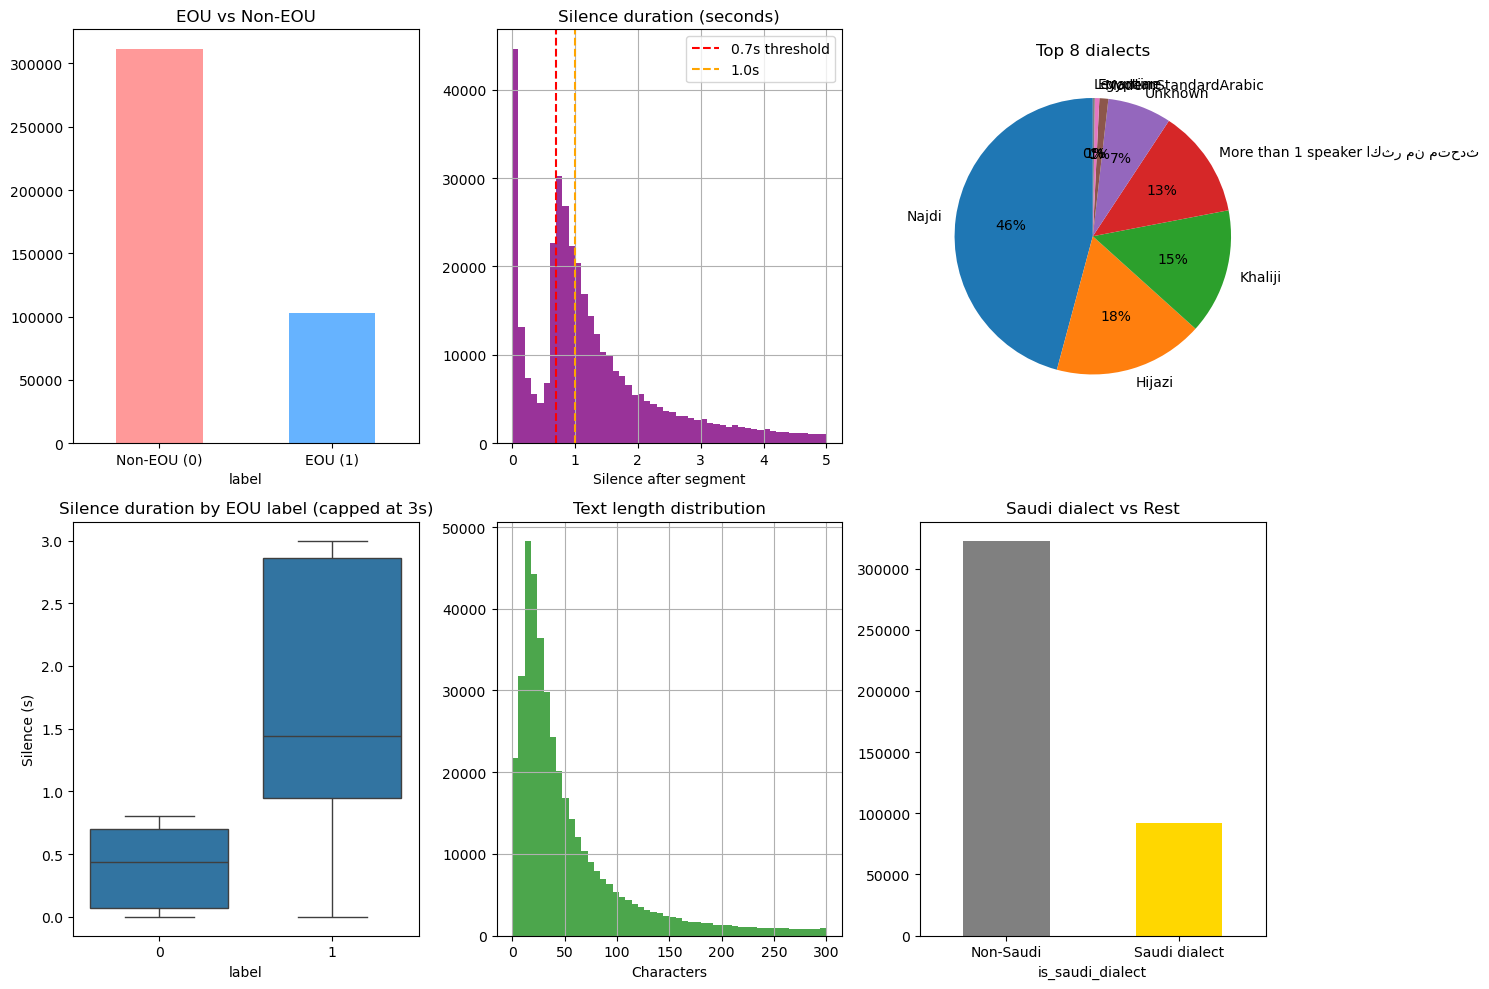

In [17]:

# ===================================
# Visualizations
# ===================================
plt.figure(figsize=(15, 10))

# 1. Label balance
plt.subplot(2, 3, 1)
df['label'].value_counts().plot(kind='bar', color=['#ff9999', '#66b3ff'])
plt.title('EOU vs Non-EOU')
plt.xticks([0,1], ['Non-EOU (0)', 'EOU (1)'], rotation=0)

# 2. Silence histogram
plt.subplot(2, 3, 2)
silence.hist(bins=50, range=(0, 5), alpha=0.8, color='purple')
plt.axvline(0.7, color='red', linestyle='--', label='0.7s threshold')
plt.axvline(1.0, color='orange', linestyle='--', label='1.0s')
plt.title('Silence duration (seconds)')
plt.xlabel('Silence after segment')
plt.legend()

# 3. Dialect pie
plt.subplot(2, 3, 3)
top_dialects = df['dialect'].value_counts().head(8)
plt.pie(top_dialects, labels=top_dialects.index, autopct='%1.0f%%', startangle=90)
plt.title('Top 8 dialects')

# 4. Silence vs Label
plt.subplot(2, 3, 4)
sns.boxplot(x='label', y=silence.clip(upper=3), data=df)
plt.title('Silence duration by EOU label (capped at 3s)')
plt.ylabel('Silence (s)')

# 5. Text length
plt.subplot(2, 3, 5)
df['text_len'].hist(bins=50, range=(0, 300), color='green', alpha=0.7)
plt.title('Text length distribution')
plt.xlabel('Characters')

# 6. Saudi vs Others
plt.subplot(2, 3, 6)
df['is_saudi_dialect'].value_counts().plot(kind='bar', color=['gray', 'gold'])
plt.title('Saudi dialect vs Rest')
plt.xticks([0,1], ['Non-Saudi', 'Saudi dialect'], rotation=0)

plt.tight_layout()
plt.show()


# README / Notes 

### Based on EDA:
- Fix 20 missing 'text' → fallback to 'raw_text'
- Fix 943 missing 'silence_after_seconds' → set to 0.0 (implies non-EOU)
- Build 'text_with_pause' for all (append [PAUSE_X.XX] if silence >=0.5)
- Drop 'augment_type' (not needed)
- Cap silence max=10s (removes weird outliers)
- Truncate long texts >512 chars (for model)
- Unify schema: only core fields
- Export: data/eou_dataset_clean.jsonl (loadable by HF)

In [18]:
import json
import math
import os

ORIGINAL_PATH = OUT_PATH  # current eou_dataset.jsonl
CLEAN_PATH = os.path.join(os.path.dirname(OUT_PATH), 'eou_dataset_clean.jsonl')

print(f'Cleaning from {ORIGINAL_PATH} → {CLEAN_PATH}')

# Core keys to keep
CORE_KEYS = ['text', 'raw_text', 'label', 'prob_label', 'start_time', 'end_time',
             'speaker_id', 'dialect', 'silence_after_seconds', 'file_name', 'split',
             'text_with_pause']

def clean_example(ex: dict) -> dict:
    cleaned = {k: ex.get(k, None) for k in CORE_KEYS}
    
    # Fix missing text
    if cleaned['text'] is None or (isinstance(cleaned['text'], str) and not cleaned['text'].strip()):
        cleaned['text'] = cleaned.get('raw_text', '')
    
    # Fix missing silence
    if cleaned['silence_after_seconds'] is None or math.isnan(cleaned['silence_after_seconds']):
        cleaned['silence_after_seconds'] = 0.0
    else:
        # Cap outliers
        cleaned['silence_after_seconds'] = min(cleaned['silence_after_seconds'], 10.0)
    
    # Build/fix text_with_pause
    base_text = cleaned['text'] or cleaned['raw_text'] or ''
    silence = cleaned['silence_after_seconds']
    if silence >= 0.5:  # From your EDA threshold
        pause_token = f' [PAUSE_{silence:.2f}]'
    else:
        pause_token = ''
    cleaned['text_with_pause'] = (base_text + pause_token)[:512]  # Truncate long
    
    # Ensure types
    cleaned['label'] = int(cleaned['label'])
    cleaned['prob_label'] = float(cleaned['prob_label']) if cleaned['prob_label'] is not None else None
    cleaned['start_time'] = float(cleaned['start_time'])
    cleaned['end_time'] = float(cleaned['end_time'])
    cleaned['silence_after_seconds'] = float(cleaned['silence_after_seconds'])
    
    return cleaned

# Process & write
cleaned_count = 0
skipped = 0
with open(ORIGINAL_PATH, 'r', encoding='utf-8') as fin, \
     open(CLEAN_PATH, 'w', encoding='utf-8') as fout:
    for line_num, line in enumerate(fin, 1):
        try:
            ex = json.loads(line.strip())
            cleaned_ex = clean_example(ex)
            fout.write(json.dumps(cleaned_ex, ensure_ascii=False) + '\n')
            cleaned_count += 1
        except Exception as e:
            skipped += 1
            print(f'Skipped line {line_num}: {e}')

print(f'\nCLEAN COMPLETE: {cleaned_count:,} examples ({skipped} skipped)')
print('Now test load:')
from datasets import load_dataset
test_ds = load_dataset('json', data_files=CLEAN_PATH, split='train[:100]')
print(f'Loaded {len(test_ds)} — keys: {list(test_ds[0].keys())}')
print('Sample:', test_ds[0])

Cleaning from c:\Users\rkhm3\Desktop\EOU_Model\data\eou_dataset.jsonl → c:\Users\rkhm3\Desktop\EOU_Model\data\eou_dataset_clean.jsonl
Skipped line 1789: unsupported operand type(s) for +: 'float' and 'str'
Skipped line 9991: unsupported operand type(s) for +: 'float' and 'str'
Skipped line 9992: unsupported operand type(s) for +: 'float' and 'str'
Skipped line 10225: unsupported operand type(s) for +: 'float' and 'str'
Skipped line 10301: unsupported operand type(s) for +: 'float' and 'str'
Skipped line 11928: unsupported operand type(s) for +: 'float' and 'str'
Skipped line 11929: unsupported operand type(s) for +: 'float' and 'str'
Skipped line 11941: unsupported operand type(s) for +: 'float' and 'str'
Skipped line 11942: unsupported operand type(s) for +: 'float' and 'str'
Skipped line 11943: unsupported operand type(s) for +: 'float' and 'str'
Skipped line 11945: unsupported operand type(s) for +: 'float' and 'str'
Skipped line 11946: unsupported operand type(s) for +: 'float' and

Generating train split: 0 examples [00:00, ? examples/s]

Loaded 100 — keys: ['text', 'raw_text', 'label', 'prob_label', 'start_time', 'end_time', 'speaker_id', 'dialect', 'silence_after_seconds', 'file_name', 'split', 'text_with_pause']
Sample: {'text': 'ووضح كلامك يا مغيث', 'raw_text': 'ووضّح كلامك يا مغيث', 'label': 1, 'prob_label': 0.7599999999999851, 'start_time': 249.72, 'end_time': 251.84, 'speaker_id': 'Speaker1متحدث', 'dialect': 'Najdi', 'silence_after_seconds': 0.8599999999999852, 'file_name': 'batch_1/6k_SBA_100_0.wav', 'split': 'train', 'text_with_pause': 'ووضح كلامك يا مغيث [PAUSE_0.86]'}
